# Dataset Loding

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('ecommerce.csv',encoding='latin1')


In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# Data Cleaning

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [10]:
df.drop('Row ID',axis=1,inplace=True)

#### Key Metrics

In [11]:
print("Total Sales: ",df['Sales'].sum())
print("Total Profit: ",df['Profit'].sum())
print("Average discount: ",df['Discount'].mean())
print("Total orders: ",df['Order ID'].nunique())


Total Sales:  2297200.8603000003
Total Profit:  286397.0217
Average discount:  0.15620272163297977
Total orders:  5009


Which Category generates the most sales?

In [12]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

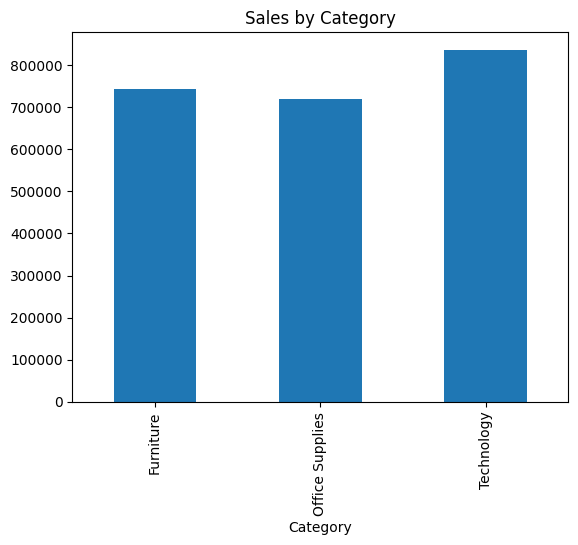

In [13]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Category')
plt.show()

Which region makes the highest profit?

In [14]:
df.groupby('Region')['Profit'].sum()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

The west is the most profitable market

In [15]:
df.groupby('Region')['Sales'].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

Which category caused most loss?

In [16]:
df.groupby('Category')['Profit'].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

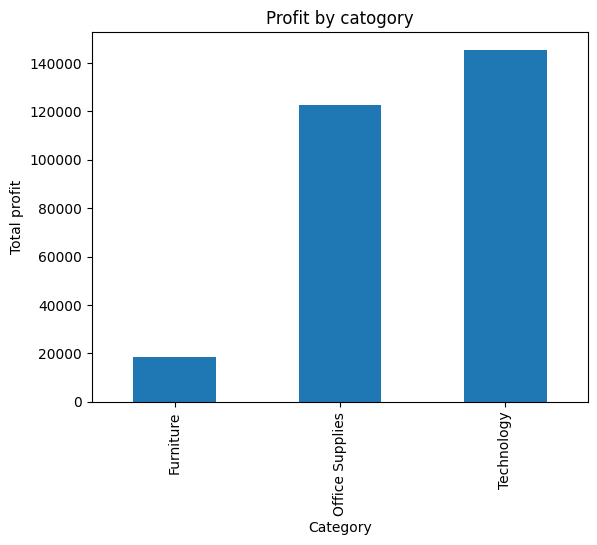

In [17]:
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Profit by catogory")
plt.ylabel("Total profit")
plt.show()

Technology products are the primary revenue drivers for the company. 

Which customer segement buys the most?

In [18]:
df.groupby('Segment')['Sales'].sum()

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

Corporate customers contribute the largest revenue.

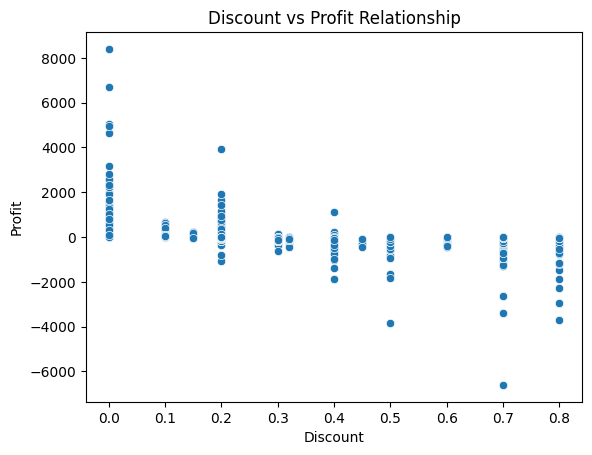

In [19]:
sns.scatterplot(x='Discount', y='Profit',data=df)
plt.title("Discount vs Profit Relationship")
plt.show()

Higher discounts are associated with lowerprofits and in many cases negetive profits. This indicates that excessive discounting significantly impacts profitability.

### Top 10 Profitable Products

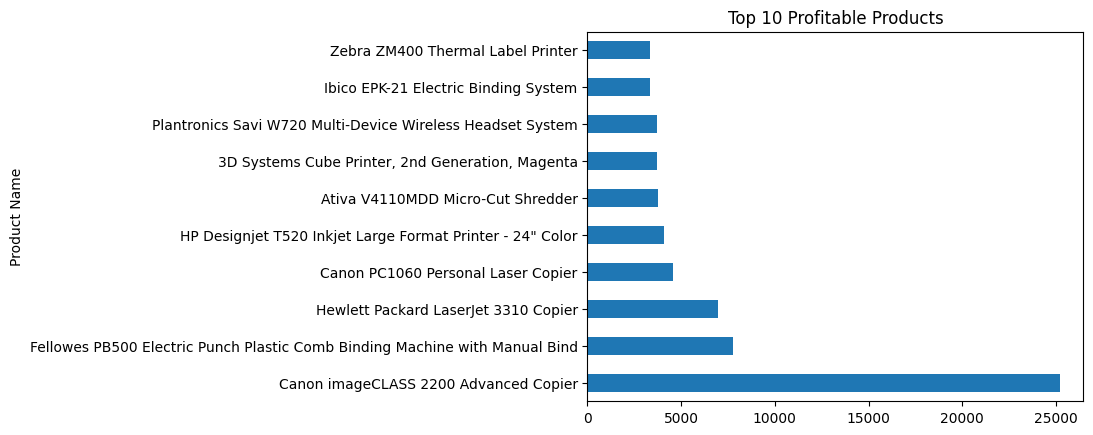

In [20]:
top_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

top_profit.plot(kind='barh')
plt.title("Top 10 Profitable Products")
plt.show()

The company should focus on promoting high-profit such as Canon imageCLASS 2200 Advanced Copier and other top-performing office equipment to maximize profitability.

### Top 10 Loss Making Products

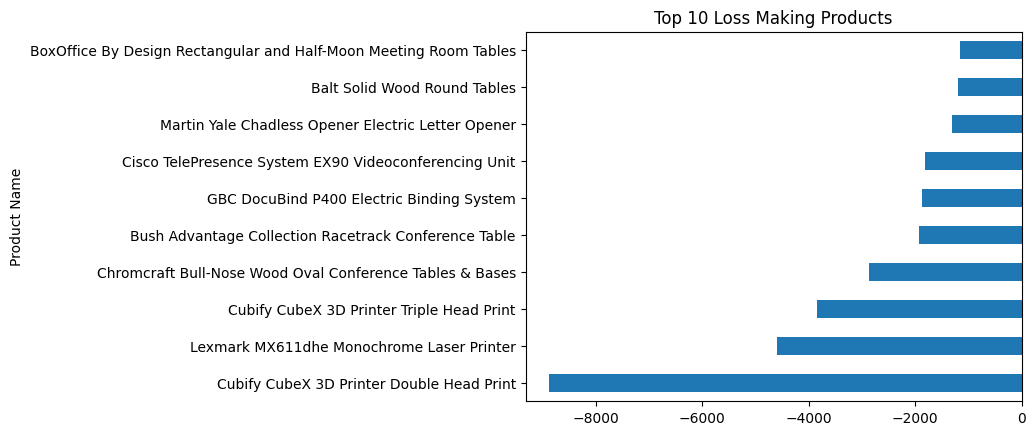

In [21]:
top_loss = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
top_loss.plot(kind='barh')
plt.title("Top 10 Loss Making Products")
plt.show()

### Monthly Sales analysis

In [22]:
df['Month'] = df['Order Date'].dt.to_period('M')


In [23]:
monthly_sales = df.groupby('Month')['Sales'].sum()

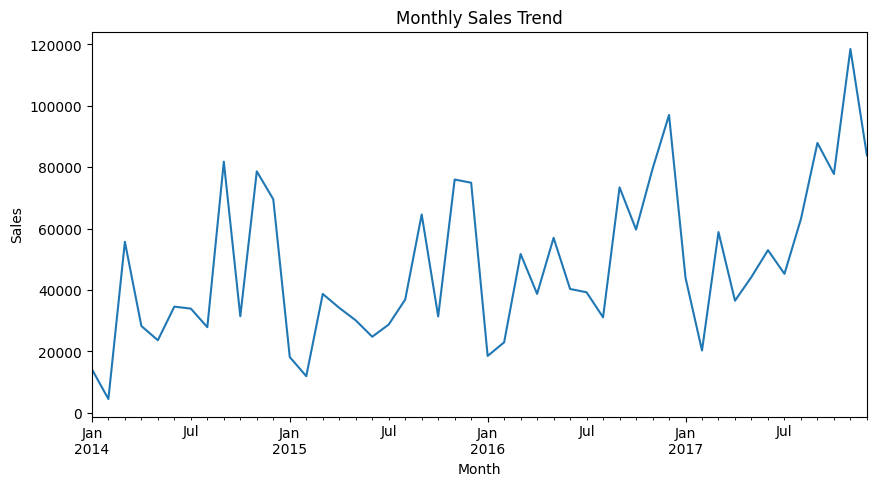

In [24]:
monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Sales fluctuate across months, with certain months showing higher demand.
Seasonal trends may influence purchasing behavior.

### Sales by region

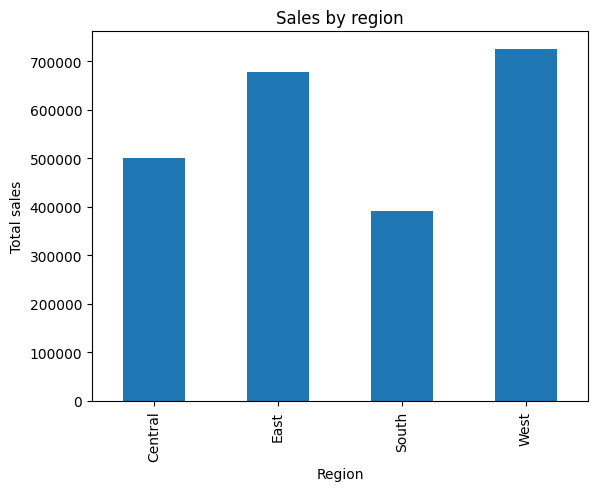

In [25]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by region")
plt.ylabel("Total sales")
plt.show()

### Profit by Segment

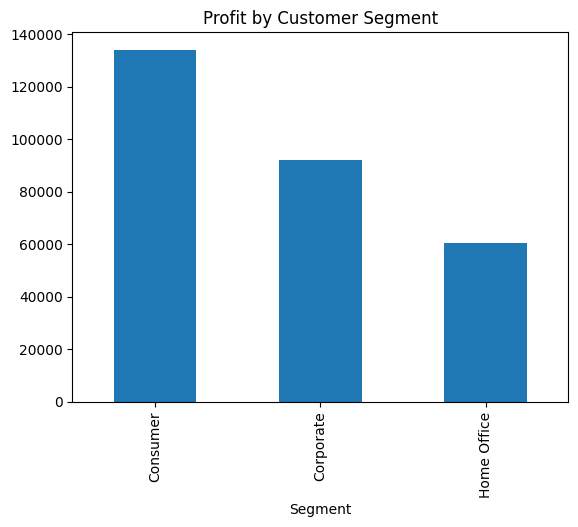

In [26]:
df.groupby('Segment')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Customer Segment")
plt.show()

In [27]:
df.groupby('Segment')['Profit'].sum()

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

The consumer segment generate highest profits among all the segment. This indicates individual retail customers contribute significantly to the company's profitability compared to corporate and Home Office segment.

Since the Consumer segment contributes the most profit, the company
should focus marketing strategies and customer retention programs
towards individual customers to maximize revenue growth.

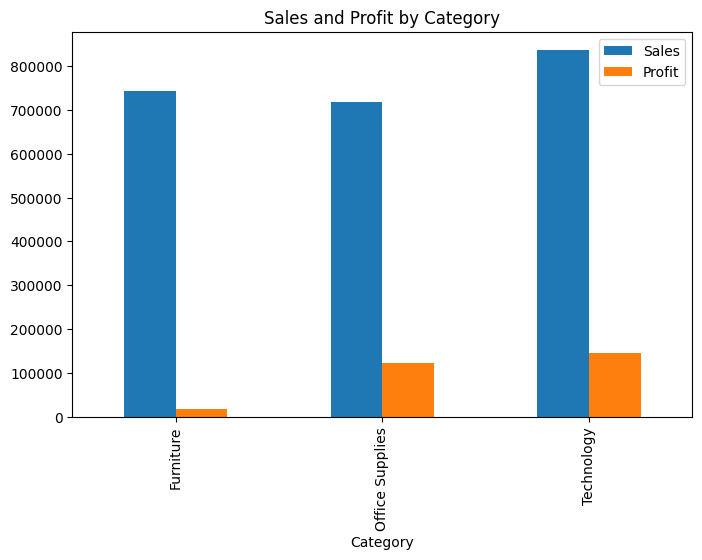

In [28]:
category_analysis = df.groupby('Category')[['Sales','Profit']].sum()
category_analysis.plot(kind='bar',figsize=(8,5))
plt.title("Sales and Profit by Category")
plt.show()

Technology generates the highest sales and profit, while Furniture
shows relatively lower profitability compared to its sales.

In [29]:
df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [30]:
df['Shipping Time'].mean()

3.958174904942966

In [31]:
df.groupby('Ship Mode')['Shipping Time'].mean()

Ship Mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: Shipping Time, dtype: float64

Different shipping modes have varying delivery times,
with standard shipping taking longer compared to express modes.

### Key Insights

1. The Technology category generates the highest sales and profit.
2. The Consumer segment contributes the highest share of total profit.
3. The West region generates the highest revenue.
4. High discounts are associated with negative profits in many orders.
5. A small number of products contribute significantly to overall profit.
6. Some products consistently generate losses and should be reviewed.
7. Sales show fluctuations across months indicating seasonal demand patterns.

### Bussiness Recommendations

1. Reduce heavy discounts on products that generate losses.
2. Focus marketing efforts on high-performing products.
3. Expand sales strategies in high-performing regions such as the West.
4. Promote Technology category products as they generate high profit.
5. Review pricing strategy for consistently loss-making products.

Saving the clean dataset for Dashboard

In [32]:
df.to_csv("clean_superstore_data.csv", index=False)

ML MODEL

##### Problem statement

Based on the features,build a ML model that predict whether a product will encure profit or loss

Create Target Variable

In [33]:
df['Profit_Label'] = df['Profit'].apply(lambda x: 1 if x > 0 else 0)

In [34]:
df['Profit_Label'].value_counts()

Profit_Label
1    8058
0    1936
Name: count, dtype: int64

In [39]:
# Selecting useful features
features = ['Category', 'Sub-Category', 'Region', 'Segment', 'Sales', 'Quantity', 'Discount']

# Independent variables
X = df[features]

# Target variable
y = df['Profit_Label']

# Check the features
X.head()

,Category,Sub-Category,Region,Segment,Sales,Quantity,Discount
0,Furniture,Bookcases,South,Consumer,261.9600,2,0.00
1,Furniture,Chairs,South,Consumer,731.9400,3,0.00
2,Office Supplies,Labels,West,Corporate,14.6200,2,0.00
3,Furniture,Tables,South,Consumer,957.5775,5,0.45
4,Office Supplies,Storage,South,Consumer,22.3680,2,0.20


In [40]:
# Convert categorical columns into numeric columns
X = pd.get_dummies(X, drop_first=True)

# Check the transformed data
X.head()

,Sales,Quantity,Discount,Category_Office Supplies,Category_Technology,Sub-Category_Appliances,Sub-Category_Art,Sub-Category_Binders,Sub-Category_Bookcases,Sub-Category_Chairs,...,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Region_East,Region_South,Region_West,Segment_Corporate,Segment_Home Office
0,261.9600,2,0.00,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
1,731.9400,3,0.00,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,14.6200,2,0.00,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
3,957.5775,5,0.45,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,22.3680,2,0.20,True,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [41]:
X = X.astype(int)

In [42]:
X.head()

,Sales,Quantity,Discount,Category_Office Supplies,Category_Technology,Sub-Category_Appliances,Sub-Category_Art,Sub-Category_Binders,Sub-Category_Bookcases,Sub-Category_Chairs,...,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Region_East,Region_South,Region_West,Segment_Corporate,Segment_Home Office
0,261,2,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
1,731,3,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2,14,2,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
3,957,5,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
4,22,2,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0


Train test Split

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic regression- Baseline Model

In [44]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

C:\Users\abhij\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [45]:
y_pred = log_model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8534267133566783

Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [49]:
y_pred_rf = rf_model.predict(X_test)

accuracy_score(y_test, y_pred_rf)

0.848424212106053

Conclusion: 

LR slighlt outperform RF on this dataset. This shows that the relationship between selected features and target variable may be relatively linear.

#### Feature Importance

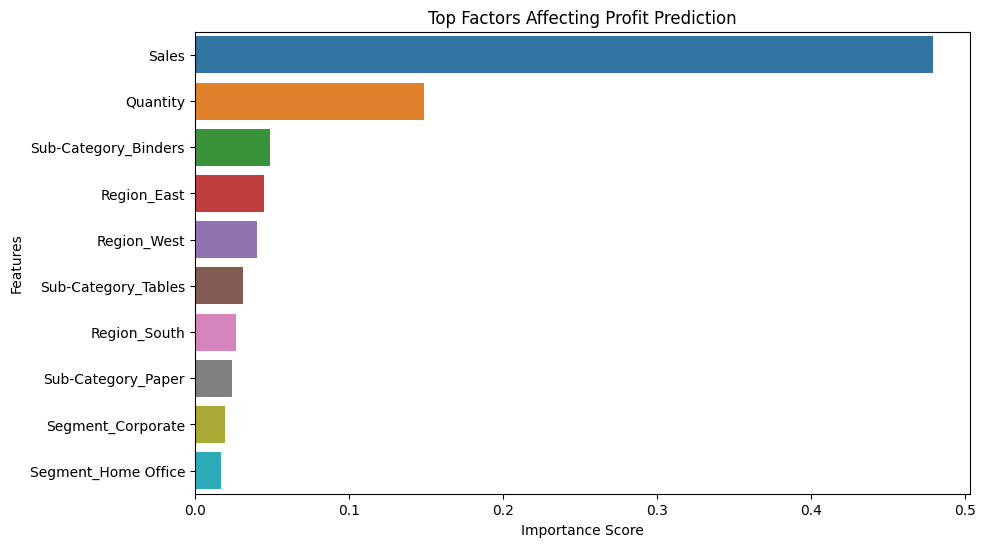

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create feature importance series
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot top 10 important features
plt.figure(figsize=(10,6))
sns.barplot(x=importance.head(10), y=importance.head(10).index)

plt.title("Top Factors Affecting Profit Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()